# Smart Energy Advisor System using Machine Learning and Artificial Neural Networks

## Submitted By:
Pankaj Singh Yadav

## Course:
CAP450 - Artificial Intelligence and Machine Learning

## Objective:
To predict household energy consumption using Machine Learning and ANN models and provide intelligent energy-saving recommendations.

# Importing Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset Loading

In [5]:

df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values='?'
)

# Take smaller sample for faster execution
df = df.sample(50000, random_state=42)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1870606,7/7/2010,18:10:00,0.256,0.106,242.00,1.2,0.0,0.0,1.0
213926,14/5/2007,06:50:00,0.466,0.352,237.22,2.4,0.0,2.0,0.0
409006,26/9/2007,18:10:00,0.758,0.194,238.66,3.2,0.0,1.0,0.0
265806,19/6/2007,07:30:00,1.290,0.046,240.64,5.4,1.0,0.0,18.0
1786279,10/5/2010,04:43:00,0.428,0.202,242.23,1.8,0.0,2.0,1.0


# Data Preprocessing

This step handles missing values and converts the dataset into a usable format for analysis and prediction.

In [8]:
# Convert Global_active_power to numeric
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

# Remove missing values
df.dropna(inplace=True)

# Create Datetime column
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
1870606,7/7/2010,18:10:00,0.256,0.106,242.00,1.2,0.0,0.0,1.0,2010-07-07 18:10:00
213926,14/5/2007,06:50:00,0.466,0.352,237.22,2.4,0.0,2.0,0.0,2007-05-14 06:50:00
409006,26/9/2007,18:10:00,0.758,0.194,238.66,3.2,0.0,1.0,0.0,2007-09-26 18:10:00
265806,19/6/2007,07:30:00,1.290,0.046,240.64,5.4,1.0,0.0,18.0,2007-06-19 07:30:00
1786279,10/5/2010,04:43:00,0.428,0.202,242.23,1.8,0.0,2.0,1.0,2010-05-10 04:43:00


# Feature Engineering

Feature engineering extracts meaningful information such as hour, day, and previous consumption from the dataset.

In [11]:

# Extract useful time features
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.dayofweek
df['month'] = df['Datetime'].dt.month

# Target variable
df['energy_consumption'] = df['Global_active_power']

# Previous consumption feature
df['past_consumption'] = df['energy_consumption'].shift(1)

# Simulated temperature feature
df['temperature'] = np.random.randint(20, 40, len(df))

# Remove NaN rows
df.dropna(inplace=True)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,hour,day,month,energy_consumption,past_consumption,temperature
213926,14/5/2007,06:50:00,0.466,0.352,237.22,2.4,0.0,2.0,0.0,2007-05-14 06:50:00,6,0,5,0.466,0.256,36
409006,26/9/2007,18:10:00,0.758,0.194,238.66,3.2,0.0,1.0,0.0,2007-09-26 18:10:00,18,2,9,0.758,0.466,22
265806,19/6/2007,07:30:00,1.290,0.046,240.64,5.4,1.0,0.0,18.0,2007-06-19 07:30:00,7,1,6,1.290,0.758,20
1786279,10/5/2010,04:43:00,0.428,0.202,242.23,1.8,0.0,2.0,1.0,2010-05-10 04:43:00,4,0,5,0.428,1.290,31
2006309,9/10/2010,23:53:00,1.206,0.302,242.10,5.0,0.0,1.0,12.0,2010-10-09 23:53:00,23,5,10,1.206,0.428,20


# Graph 1 - Hourly Household Energy Consumption Analysis

In [82]:
print(lr.coef_)

[-0.00247078  0.04311886  0.03861786  0.00265695]


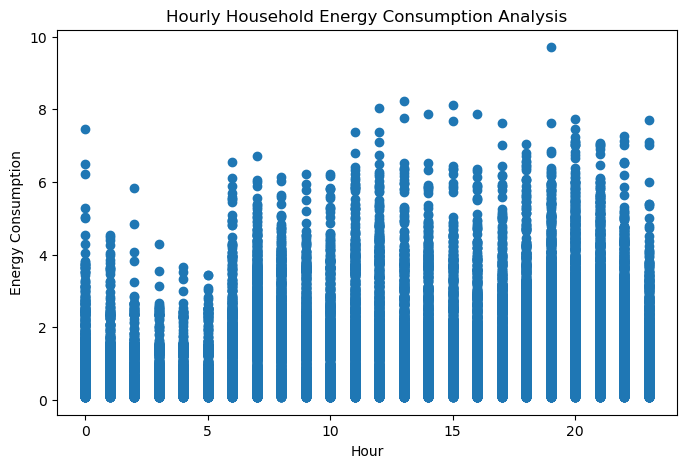

In [13]:

plt.figure(figsize=(8,5))

plt.scatter(
    df['hour'],
    df['energy_consumption']
)

plt.xlabel("Hour")
plt.ylabel("Energy Consumption")
plt.title("Hourly Household Energy Consumption Analysis")

plt.show()

# Graph 2 - Average Consumption by Hour

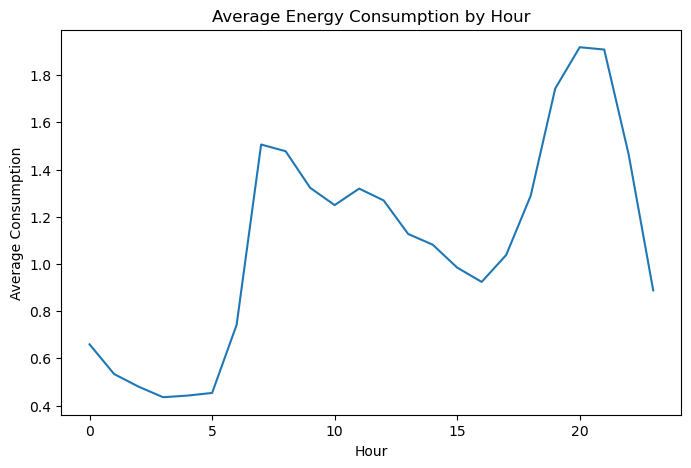

In [15]:
hourly_avg = df.groupby('hour')['energy_consumption'].mean()

plt.figure(figsize=(8,5))

hourly_avg.plot()

plt.xlabel("Hour")
plt.ylabel("Average Consumption")
plt.title("Average Energy Consumption by Hour")

plt.show()

# Model Training

In [17]:
from sklearn.model_selection import train_test_split

X = df[['temperature', 'hour', 'day', 'past_consumption']]
y = df['energy_consumption']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression Model

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# Random Forest Model

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Evaluation

In [23]:
from sklearn.metrics import mean_absolute_error

print(
    "Linear Regression MAE:",
    mean_absolute_error(y_test, lr_pred)
)

print(
    "Random Forest MAE:",
    mean_absolute_error(y_test, rf_pred)
)

Linear Regression MAE: 0.7664118121109617
Random Forest MAE: 0.7226165361375179


# SMART ENERGY SUGGESTION SYSTEM

In [84]:
def give_suggestions(temp, hour, consumption):

    if consumption > 5:
        return "⚠️ High energy usage expected. Reduce heavy appliance usage."

    elif temp > 30:
        return "Use AC efficiently to reduce consumption."

    elif 18 <= hour <= 22:
        return "Avoid peak hour electricity usage."

    else:
        return "Energy usage is normal."

# Sample Prediction

In [27]:
sample = [[32, 19, 2, 3.5]]

sample_df = pd.DataFrame(
    [[32, 19, 2, 3.5]],
    columns=['temperature', 'hour', 'day', 'past_consumption']
)

prediction = rf.predict(sample_df)[0]
print("Predicted Energy Consumption:", prediction)

print(
    give_suggestions(
        temp=32,
        hour=19,
        consumption=prediction
    )
)

Predicted Energy Consumption: 1.9906799999999998
Use AC efficiently to reduce consumption.


# Graph 3 - Comparison (Actual vs Predicted) Linear Regression

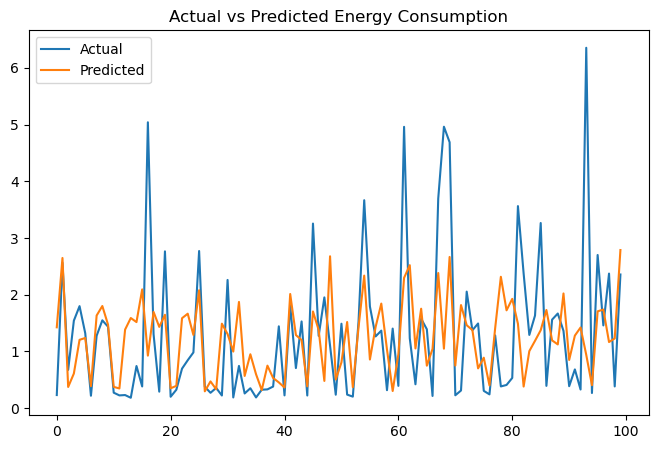

In [28]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(rf_pred[:100], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Energy Consumption")

plt.show()

# Artificial Neural Network using MLPRegressor

An Artificial Neural Network (ANN) is implemented using MLPRegressor to improve prediction accuracy using hidden layers and activation functions.

# Importing Required Libraries


In [32]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Feature Scaling

In [34]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ANN Model

In [36]:
ann = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    max_iter=300,
    random_state=42
)

# Train Model

In [38]:
ann.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=300, random_state=42)

# Predictions

In [40]:
ann_pred = ann.predict(X_test_scaled)

# Evaluation

In [42]:
print(
    "ANN MAE:",
    mean_absolute_error(y_test, ann_pred)
)

ANN MAE: 0.6688455965403061


# Graph 3 - Loss Curve

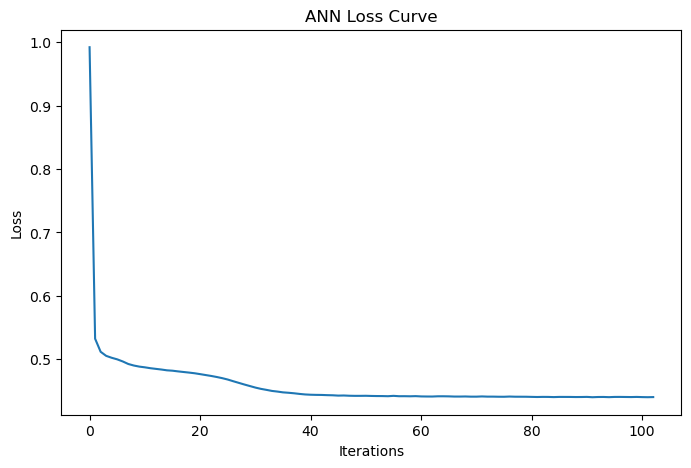

In [44]:
plt.figure(figsize=(8,5))

plt.plot(ann.loss_curve_)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("ANN Loss Curve")

plt.show()

# Final Model Comparison Table

In [46]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'ANN'
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, ann_pred)
    ]
})

results

,Model,MAE
0,Linear Regression,0.766412
1,Random Forest,0.722617
2,ANN,0.668846


# Graph 4 - Comparison (Actual vs Predicted Energy Consumption)

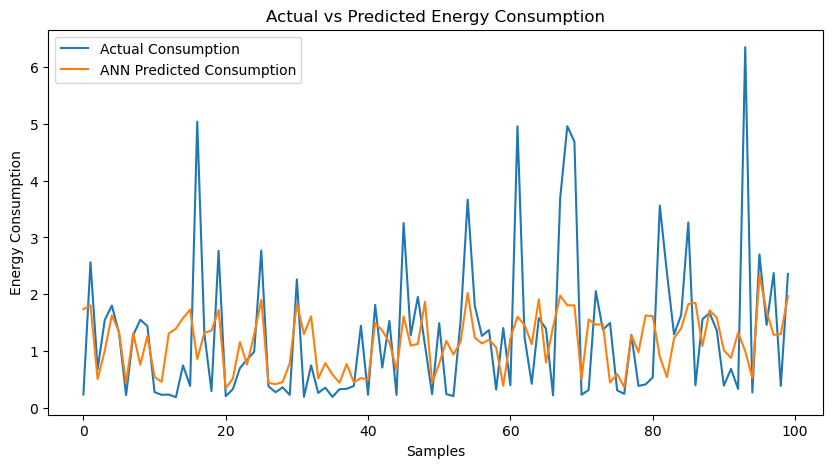

In [48]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label='Actual Consumption'
)

plt.plot(
    ann_pred[:100],
    label='ANN Predicted Consumption'
)

plt.xlabel("Samples")
plt.ylabel("Energy Consumption")

plt.title("Actual vs Predicted Energy Consumption")

plt.legend()

plt.show()

# Conclusion
The Smart Energy Advisor System successfully predicts household energy consumption using Machine Learning and Artificial Neural Network techniques.

The project includes data preprocessing, feature engineering, visualization, regression models, Random Forest, and ANN implementatio.

Among all implemented models, the ANN model achieved the best performance with the lowest Mean Absolute Error (ME).

The system also provides intelligent recommendations to optimize electricity usage and reduce unnecessary energy consumption..uracy.